In [1]:
import h5py
import numpy as np
import pandas as pd
import os

from methylseqnet.motifs import split_h5_by_string, parse_h5_file, print_h5_structure, h5_to_dataframe

In [3]:
# PWMs for selection, or otherwise for each human CIS-BP TF (~700)
TFS = []
if os.path.exists('transcription_factors.txt'):
    with open('transcription_factors.txt', 'r') as file:
        TFS = file.read().splitlines()
else:
    TFS = os.listdir(f"{PWMS_TOP_DIR}/pwms/")
    TFS = [t.split(".csv")[0] for t in TFS]
print(f"TFs are: {TFS}")
print(f"{len(TFS)} TFs total")

TFs are: ['AHR', 'AIRE', 'ZNF143']
3 TFs total


## Example splitting, averaging, and analyzing predictions

Note: loading the full file may be prohobitive, working with the TF-split files is easier

In [3]:
# Example Usage:
# tfs = ['TRANS_1', 'TRANS_2', 'REG_A', 'REG_B', 'SIG_X']
# split_h5_by_string('input_data.h5', tfs)

preds_file = '/global/scratch/users/arbajwa/datasets/atac_atlas/preprocessed_peaks/Hepatocyte_peaks_test_small/slurm29336762task4/motif_insertions/predictions.h5'

TFS = ['AHR', 'AIRE', 'ZNF143']
output_path = '/global/scratch/users/arbajwa/datasets/atac_atlas/preprocessed_peaks/Hepatocyte_peaks_test_small/slurm29336762task4/motif_insertions/split'

split_h5_by_string(preds_file, TFS, output_path)

Processed 126945/126945 rows...
 Finished! Files located at: /global/scratch/users/arbajwa/datasets/atac_atlas/preprocessed_peaks/Hepatocyte_peaks_test_small/slurm29336762task4/motif_insertions/split


In [2]:
# TODO: make this more modular by tf
ahr_path = '/global/scratch/users/arbajwa/datasets/atac_atlas/preprocessed_peaks/Hepatocyte_peaks_test_small/slurm29336762task4/motif_insertions/split/predictions_AHR.h5'
AHR_df = h5_to_dataframe(ahr_path, dataset_name='specifier')

In [3]:
AHR_df

,specifier
0,b'/global/scratch/users/arbajwa/datasets/atac_...
1,b'/global/scratch/users/arbajwa/datasets/atac_...
2,b'/global/scratch/users/arbajwa/datasets/atac_...
3,b'/global/scratch/users/arbajwa/datasets/atac_...
4,b'/global/scratch/users/arbajwa/datasets/atac_...
...,...
42310,b'/global/scratch/users/arbajwa/datasets/atac_...
42311,b'/global/scratch/users/arbajwa/datasets/atac_...
42312,b'/global/scratch/users/arbajwa/datasets/atac_...
42313,b'/global/scratch/users/arbajwa/datasets/atac_...


In [4]:
len(AHR_df)

42315

In [5]:
ahr_path = '/global/scratch/users/arbajwa/datasets/atac_atlas/preprocessed_peaks/Hepatocyte_peaks_test_small/slurm29336762task4/motif_insertions/split/predictions_AHR.h5'
ahr_preds = parse_h5_file(ahr_path)

Keys in the file: ['predictions', 'specifier']
Data shape: (42315, 1, 65, 1536)


In [6]:
ahr_preds

array([[[[3.38797003e-01, 3.29046041e-01, 3.21954906e-01, ...,
          3.72845940e-02, 4.48790342e-02, 1.37586534e-01],
         [1.42617851e-01, 1.55087799e-01, 1.41845793e-01, ...,
          1.23019479e-01, 1.93445206e-01, 2.80472666e-01],
         [1.08599460e+00, 1.00601530e+00, 1.02257860e+00, ...,
          4.91308048e-02, 4.90475111e-02, 1.03116639e-01],
         ...,
         [5.56549311e-01, 5.60987473e-01, 5.81089616e-01, ...,
          4.83690724e-02, 5.21811917e-02, 8.06136429e-02],
         [3.84438515e-01, 3.74647558e-01, 3.97971958e-01, ...,
          8.48454535e-02, 9.29039791e-02, 1.43697307e-01],
         [8.20214767e-03, 9.17926989e-03, 7.85448309e-03, ...,
          3.95779079e-03, 4.51563159e-03, 3.89344129e-03]]],


       [[[3.40372115e-01, 3.30631256e-01, 3.23533863e-01, ...,
          3.73568274e-02, 4.49311696e-02, 1.37960628e-01],
         [1.42331913e-01, 1.54772595e-01, 1.41556934e-01, ...,
          1.23596393e-01, 1.94264203e-01, 2.81449527e-01],
      

In [7]:
ahr_preds.shape

(42315, 1, 65, 1536)

In [8]:
# If we did N=5 trials before, we should
# take the average over every N=5 rows:
N = 5
# TODO: sanity check N against the specifiers once preprocessing bug fixed

print(ahr_preds.shape)

# Captures trailing dimensions after the first using preds.shape[1:]
# Reshapes to (-1, N, ...trailing dimensions...)
# Computes the mean along the new axis 1
averaged_preds = ahr_preds.reshape(-1, N, *ahr_preds.shape[1:]).mean(axis=1)

print(averaged_preds.shape)

(42315, 1, 65, 1536)
(8463, 1, 65, 1536)


In [9]:
track_idx = 1 #Hepatocytes, found from human readable track lookup table
center_bin_idx = averaged_preds.shape[-1]//2 #half of bin dimension size

relevant_preds = averaged_preds[:, :, track_idx:track_idx+1, center_bin_idx:center_bin_idx+1]

relevant_preds

array([[[[0.17738123]]],


       [[[0.4301898 ]]],


       [[[0.7015947 ]]],


       ...,


       [[[0.06135816]]],


       [[[0.13117364]]],


       [[[0.00182428]]]], dtype=float32)

In [10]:
relevant_preds.shape

(8463, 1, 1, 1)

In [11]:
# Compute the histogram data
counts, bin_edges = np.histogram(relevant_preds.squeeze(), bins=100)

print("Counts:", counts)
print("Bin Edges:", bin_edges)

Counts: [6680  380  231  167  153  124   94   97   72   66   44   51   47   45
   26   33   25   16   18   20    9    9    9    3    4    7    4    4
    3    0    4    3    1    0    1    1    0    0    1    4    0    0
    1    1    0    0    1    0    0    0    0    0    1    0    0    1
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    1    0    0
    0    1]
Bin Edges: [9.6527029e-11 2.8963680e+00 5.7927361e+00 8.6891041e+00 1.1585472e+01
 1.4481840e+01 1.7378208e+01 2.0274576e+01 2.3170944e+01 2.6067312e+01
 2.8963680e+01 3.1860048e+01 3.4756416e+01 3.7652786e+01 4.0549152e+01
 4.3445518e+01 4.6341888e+01 4.9238258e+01 5.2134624e+01 5.5030991e+01
 5.7927361e+01 6.0823730e+01 6.3720097e+01 6.6616463e+01 6.9512833e+01
 7.2409203e+01 7.5305573e+01 7.8201935e+01 8.1098305e+01 8.3994675e+01
 8.6891037e+01 8.9787407e+01 9.2683777e+01 9.5

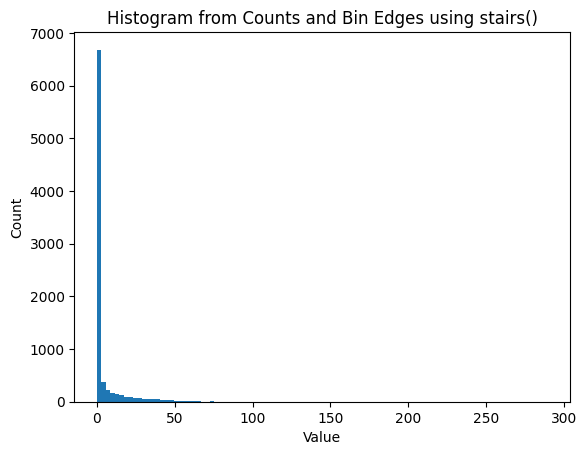

In [12]:
import matplotlib.pyplot as plt

# Plot the histogram using plt.stairs()
# fill=True provides a solid bar appearance
plt.stairs(counts, edges=bin_edges, fill=True, edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Histogram from Counts and Bin Edges using stairs()')
plt.show()

In [4]:
# TODO: get on-the-fly predictions from the endogenous sequences

In [ ]:
# TODO: calculate variant effect predictions (deltas) between endogenous and (averaged) inserted sequence

## Check full preds file from predict

In [13]:
preds_file = '/global/scratch/users/arbajwa/datasets/atac_atlas/preprocessed_peaks/Hepatocyte_peaks_test_small/slurm29336762task4/motif_insertions/predictions.h5'

In [14]:
with h5py.File(preds_file, 'r') as hf:
    hf.visititems(print_h5_structure)

indices -> <class 'h5py._hl.dataset.Dataset'>
predictions -> <class 'h5py._hl.dataset.Dataset'>
specifier -> <class 'h5py._hl.dataset.Dataset'>


In [15]:
preds = parse_h5_file(preds_file)

Keys in the file: ['indices', 'predictions', 'specifier']
Data shape: (126945, 1, 65, 1536)


In [16]:
preds

array([[[[3.26051503e-01, 3.35340679e-01, 3.46277416e-01, ...,
          3.73793915e-02, 4.49579135e-02, 1.38049051e-01],
         [2.45930299e-01, 2.18963563e-01, 1.63407207e-01, ...,
          1.23764873e-01, 1.94306239e-01, 2.81712264e-01],
         [8.37189034e-02, 7.43542612e-02, 7.32048154e-02, ...,
          4.90623377e-02, 4.89990003e-02, 1.02936476e-01],
         ...,
         [1.71722472e-01, 1.54052600e-01, 1.52375147e-01, ...,
          4.83280756e-02, 5.21503873e-02, 8.06301013e-02],
         [2.02052116e-01, 1.91837117e-01, 1.93227261e-01, ...,
          8.46512318e-02, 9.27399844e-02, 1.43584654e-01],
         [6.19690353e-03, 7.00288452e-03, 5.55970706e-03, ...,
          3.97473667e-03, 4.53385571e-03, 3.90902394e-03]]],


       [[[3.37699503e-01, 3.27997774e-01, 3.20834249e-01, ...,
          3.72809432e-02, 4.48902473e-02, 1.37881771e-01],
         [1.41894683e-01, 1.54319048e-01, 1.41128689e-01, ...,
          1.23281874e-01, 1.93713695e-01, 2.80680656e-01],
      

In [17]:
preds.shape

(126945, 1, 65, 1536)

In [18]:
# free up memory
del preds

In [19]:
preds_df = h5_to_dataframe(preds_file)
# TODO: tends to hit a memory error, see if I can make the helper functions more efficient?
# TODO: otherwise,

In [20]:
preds_df

,specifier
0,b'/global/scratch/users/arbajwa/datasets/atac_...
1,b'/global/scratch/users/arbajwa/datasets/atac_...
2,b'/global/scratch/users/arbajwa/datasets/atac_...
3,b'/global/scratch/users/arbajwa/datasets/atac_...
4,b'/global/scratch/users/arbajwa/datasets/atac_...
...,...
126940,b'/global/scratch/users/arbajwa/datasets/atac_...
126941,b'/global/scratch/users/arbajwa/datasets/atac_...
126942,b'/global/scratch/users/arbajwa/datasets/atac_...
126943,b'/global/scratch/users/arbajwa/datasets/atac_...
